<a href="https://colab.research.google.com/github/Arggeiser07/ML-DL-IA/blob/main/Primera_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Proyecto sencillo que procesa números NO escritos por una máquina, es decir, con sus defectos de escritura como los tendría un humano; e intuye el número correcto simulando la lectura humana. Hecho con con una Red Neuronal Convolucional, específicas para procesar imágenes.

In [ ]:
#Importaciones
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# Carga de datos
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalización y Reshape (Importante: añadimos el canal 1 para gris)
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print(f"Forma de x_train: {x_train.shape}") # Debería ser (60000, 28, 28, 1)


Forma de x_train: (60000, 28, 28, 1)


In [ ]:
#Instancia del modelo
model = models.Sequential([
    # Bloque 1: Escáner inicial
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    # Bloque 2: Escáner de rasgos complejos
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Bloque 3: Traducción a lógica (Tu "cerebro" MLP)
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') # 10 neuronas para los números 0-9
])

model.summary() # Para ver cómo se reduce la imagen


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Instancia del modelo
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Tu configuración de Early Stopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


In [ ]:
#Entrenamiento
history = model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)


Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 55ms/step - accuracy: 0.9368 - loss: 0.2113 - val_accuracy: 0.9778 - val_loss: 0.0766
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 55ms/step - accuracy: 0.9821 - loss: 0.0596 - val_accuracy: 0.9839 - val_loss: 0.0561
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.9874 - loss: 0.0410 - val_accuracy: 0.9866 - val_loss: 0.0469
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - accuracy: 0.9895 - loss: 0.0327 - val_accuracy: 0.9882 - val_loss: 0.0414
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.9922 - loss: 0.0253 - val_accuracy: 0.9880 - val_loss: 0.0419
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - accuracy: 0.9932 - loss: 0.0205 - val_accuracy: 0.9879 - val_loss: 0.0451
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - accuracy: 0.9950 - loss: 0.0143 - val_accuracy: 0.9889 - val_loss: 0.0419


In [ ]:
# Evaluación final
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'\nPrecisión en Test: {test_acc*100:.2f}%')

# Predicción individual
import numpy as np
predicciones = model.predict(x_test)
print(f"Predicción de la primera imagen: {np.argmax(predicciones[0])}")
print(f"Valor real: {y_test[0]}")


313/313 - 3s - 8ms/step - accuracy: 0.9879 - loss: 0.0356

Precisión en Test: 98.79%
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Predicción de la primera imagen: 7
Valor real: 7


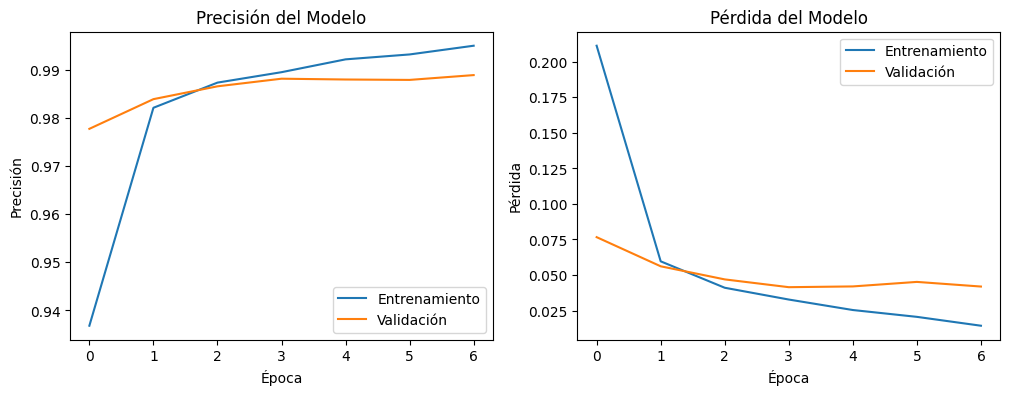

In [ ]:
# Crear una figura con dos gráficos (Lado a lado)
plt.figure(figsize=(12, 4))

# Gráfico 1: Precisión (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del Modelo')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()

# Gráfico 2: Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida del Modelo')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

plt.show()


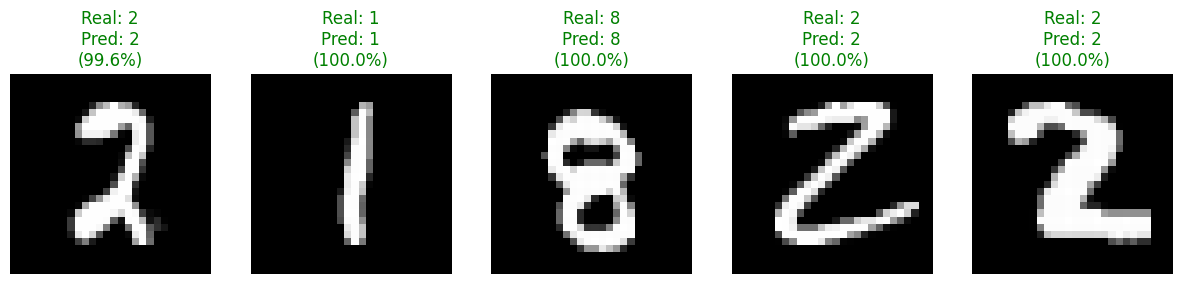

In [ ]:
import numpy as np

# 1. Elegir 5 índices al azar del set de test
indices = np.random.choice(range(len(x_test)), 5)

plt.figure(figsize=(15, 5))

for i, idx in enumerate(indices):
    # Obtener la imagen y su etiqueta real
    img = x_test[idx]
    label_real = y_test[idx]

    # Hacer la predicción (añadimos una dimensión extra para que el modelo la acepte)
    prediccion = model.predict(img.reshape(1, 28, 28, 1), verbose=0)
    label_predicha = np.argmax(prediccion)
    confianza = np.max(prediccion) * 100

    # Dibujar la imagen
    plt.subplot(1, 5, i + 1)
    plt.imshow(img.reshape(28, 28), cmap='gray')

    # Título en verde si acertó, rojo si falló
    color = 'green' if label_predicha == label_real else 'red'
    plt.title(f"Real: {label_real}\nPred: {label_predicha}\n({confianza:.1f}%)", color=color)
    plt.axis('off')

plt.show()
